#PARCIAL 1 / DEEP LEARNING

> **Integrante:** Sebastian Vallejos

---

#**1. Desarrollo**

##**1.1 Importamos las librerias que se usaran para  el desarrollo**
---


Se importa la libreria `Keras` necesaria para la creacion, el entrenamiento y testeo del modelo. Tambien se trabajara en el framework `Tensorflow`. De igual manera se utilizaran las librerias `Numpy` y `PyPlot` de `Matplotlib` para graficar y hacer operaciones matematicas mas rapidas.


In [207]:
from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

##**1.2 Descargamos los datos que se usaran para el modelo**
---

Se descargan los datasets `Fashion_MNIST` de keras que se usaran para el entrenamiento y testeo del modelo.

In [138]:
#Se cargan los datos de entrenamiento
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()


print(train_images.shape, test_images.shape)

(60000, 28, 28) (10000, 28, 28)


##**1.3 Usamos `PyPlot` para ver las imagenes que se usaran**
---

Se utiliza PyPlot como `plt` para tener una representacion visual de que es lo que usara el modelo para entrenarse






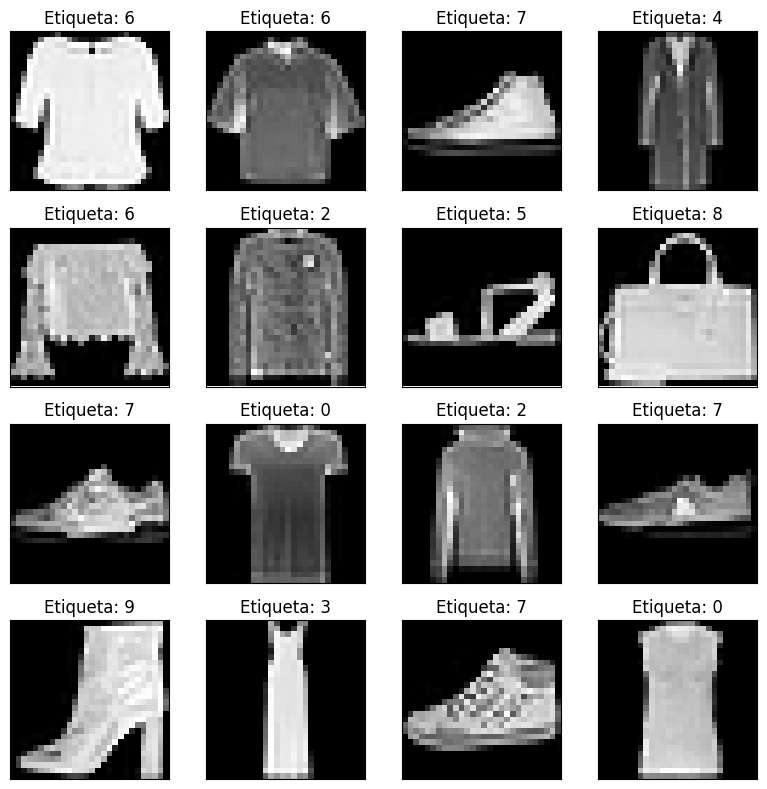

In [139]:
h = 4 #alto de la grilla
w = 4 #ancho de la grilla

# Creamos la figura y los ejes
fig, axs = plt.subplots(h, w, figsize=(8, 8))

# Usamos un bucle para llenar cada espacio de la grilla
for i in range(h):
    for j in range(w):
        # Elegimos un índice al azar de los datos de entrenamiento
        ex = np.random.randint(len(train_images))

        # Mostramos la imagen
        axs[i,j].imshow(train_images[ex], cmap='gray')

        # Configuramos el título con la etiqueta correspondiente
        axs[i,j].set_title("Etiqueta: " + str(train_labels[ex]))

        # Eliminamos los ejes para que se vea más limpio
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].grid(False)

# Ajustamos el espaciado para que no se encimen los títulos
plt.tight_layout()
plt.show()

##**1.4 Realizamos el flattening, Normalizacion y One-hot coding**
---

> **1.4.1 Aplanar (Flattening)**

Aplanamos las imagenes con `.reshape()` para que el modelo pueda procesar las imagenes y usarlas para entrenar.

> **1.4.2 Normalizar**

Normalizamos las imagenes `dividiendo por 255` para que el modelo sea mas estable y no entrene con numeros tan grandes

> **1.4.3 One-Hot coding**

Usamos One-Hot coding para que el modelo puedo entrenarse correctamente




In [140]:
#1.4.1 Hacemos flattening
X_train_images = train_images.reshape(60000, 28*28)
X_test_images = test_images.reshape(10000, 28*28)

#1.4.2 Normalizamos
X_train_images = X_train_images / 255
X_test_images = X_test_images / 255

#1.4.3 One-hot coding
Y_train_labels = keras.utils.to_categorical(train_labels, 10)
Y_test_labels = keras.utils.to_categorical(test_labels, 10)

print(Y_train_labels.shape, Y_test_labels.shape)


(60000, 10) (10000, 10)


In [142]:
#Cantidad de ejemplos
M = X_train_images.shape[0]

#cantidad de neuronas de entrada
N = X_train_images.shape[1]

#neuronas de salida
C = Y_train_labels.shape[1]

print(f'Cantidad de ejemplos (imagenes) que se usaran para entrenar: {M}')
print(f'Cantidad de neuronas que se neceistan por capa: {N}')
print(f'Cantidad de respuestas posibles: {C}')


Cantidad de ejemplos (imagenes) que se usaran para entrenar: 60000
Cantidad de neuronas que se neceistan por capa: 784
Cantidad de respuestas posibles: 10


##**1.5 Definimos las capas ocultas y las semillas**
---

In [178]:
#Seeds
np.random.seed(45)
tf.random.set_seed(45)

#capas ocultas (2 capas ocultas!)
c1 = 64
c2 = 32

##**1.6 Creamos la red con una funcion de activacion `Leaky ReLu` y una funcion de salida `Softmax`**
---

In [183]:
#muestra red feed-forward

red = keras.Sequential()
red.add(keras.layers.Dense(c1, input_dim=N, activation='leaky_relu', name='primera_capa'))
red.add(keras.layers.Dense(c2, activation='leaky_relu', name='segunda_capa'))
red.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ primera_capa (Dense)            │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segunda_capa (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_de_output (Dense)          │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

> Entrenamos la red usando el optimizador sgd, graficando el porcentaje de aciertos, la perdida y revisando si se sobreajusto el modelo


In [184]:
#compilamos la red para entrenar
red.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=['accuracy']
)


In [185]:
#Entrenamos
h = red.fit(X_train_images, Y_train_labels,
        epochs=30,
        batch_size=128,
        validation_data=(X_test_images, Y_test_labels)
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6138 - loss: 1.1564 - val_accuracy: 0.7077 - val_loss: 0.7900
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7589 - loss: 0.6893 - val_accuracy: 0.7728 - val_loss: 0.6442
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7968 - loss: 0.5916 - val_accuracy: 0.7944 - val_loss: 0.5820
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8131 - loss: 0.5433 - val_accuracy: 0.8076 - val_loss: 0.5474
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8220 - loss: 0.5134 - val_accuracy: 0.8151 - val_loss: 0.5246
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8288 - loss: 0.4926 - val_accuracy: 0.8217 - val_loss: 0.5082
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8338 - loss: 0.4769 - val_accuracy: 0.8256 - val_loss: 0.4954
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8384 - loss: 0.4644 - val_accuracy: 0.

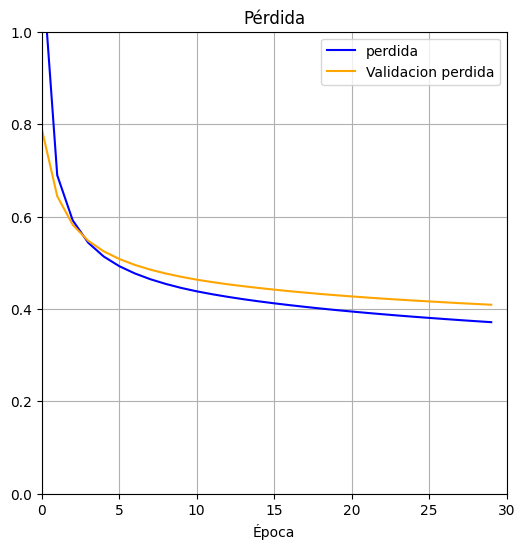

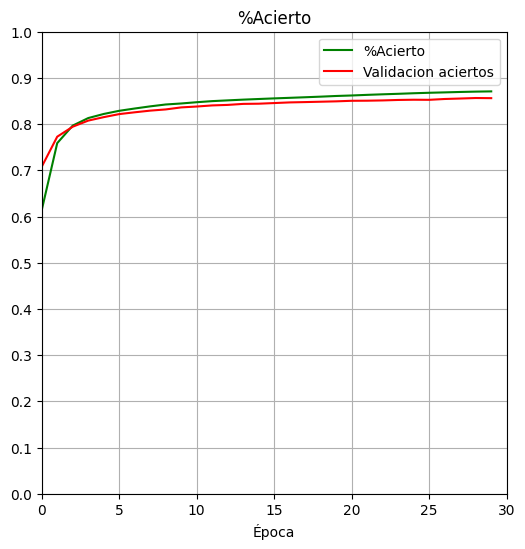

In [186]:
#Tamaño de la cuadricula de perdida
plt.figure(figsize=(6,6))

#Imprimimos la perdida en cada epoca
plt.plot(h.history['loss'], color="blue", label="perdida")
plt.plot(h.history['val_loss'], color="orange", label="Validacion perdida")

plt.title('Pérdida')
plt.legend()
plt.axis([0,30,0,1])
#plt.yticks(np.arange(0, 0.51, 0.1))
plt.xlabel('Época')
plt.grid(True)
plt.show()

#Tamaño cuadricula de aciertos
plt.figure(figsize=(6,6))

#Imprimimos los aciertos en cada epoca
plt.plot(h.history['accuracy'], color="green", label="%Acierto")
plt.plot(h.history['val_accuracy'], color="red", label="Validacion aciertos")

plt.title('%Acierto')
plt.legend()
plt.axis([0,30,0,1])
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xlabel('Época')
plt.grid(True)
plt.show()

###**1.6.2 Analisis de `red`**

En el modelo `red` utilizamos la funcion de activacion `Leaky ReLu`, funcion de salida `softmax` y de optimizer `sgd`. al graficar los resultados del entrenamiento junto a que tan bien le fue al analizar imagenes que nunca antes habia visto el modelo podemos ver que en cuanto a la perdida (loss) parece tender a 0.4 lo cual indica que el modelo tiene un margen para generalizar decente.

Por otro lado, podemos observar como en los aciertos el modelo se mantuvo en 0,85 aproximadamente. Esto nos indica que el modelo en el 85% del analisis de nuevos datos los va a interpretar de manera correcta.

Si bien estos son buenos numeros para el modelo, se pueden mejorar aplicando regularizacion o cambiando de optimizer.

##**1.7 Utilizando `dropout` para regularizar. Tambien cambiamos de optimizer a `Adam` y usamos `ReLu` como funcion de activacion**
---

In [170]:
#Probemos regularizando con dropout

red2 = keras.Sequential()
red2.add(keras.layers.Dense(c1, input_dim=N, activation='relu', name='primera_capa'))
red2.add(keras.layers.Dropout(0.3))
red2.add(keras.layers.Dense(c2, activation='relu', name='segunda_capa'))
red2.add(keras.layers.Dropout(0.3))
red2.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red2.summary()

#compilamos la red para entrenar y cambiamos el optimizer por Adam
red2.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=['accuracy']
)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ primera_capa (Dense)            │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segunda_capa (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_de_output (Dense)          │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [171]:
h2 = red2.fit(X_train_images, Y_train_labels,
        epochs=35,
        batch_size=128,
        validation_data=(X_test_images, Y_test_labels)
)

Epoch 1/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6806 - loss: 0.9059 - val_accuracy: 0.8201 - val_loss: 0.5139
Epoch 2/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7972 - loss: 0.5828 - val_accuracy: 0.8390 - val_loss: 0.4520
Epoch 3/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8177 - loss: 0.5204 - val_accuracy: 0.8507 - val_loss: 0.4207
Epoch 4/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8300 - loss: 0.4866 - val_accuracy: 0.8546 - val_loss: 0.4074
Epoch 5/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8367 - loss: 0.4668 - val_accuracy: 0.8540 - val_loss: 0.4047
Epoch 6/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8414 - loss: 0.4504 - val_accuracy: 0.8606 - val_loss: 0.3934
Epoch 7/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8468 - loss: 0.4391 - val_accuracy: 0.8579 - val_loss: 0.3920
Epoch 8/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8486 - loss: 0.4298 - val_accuracy: 0.

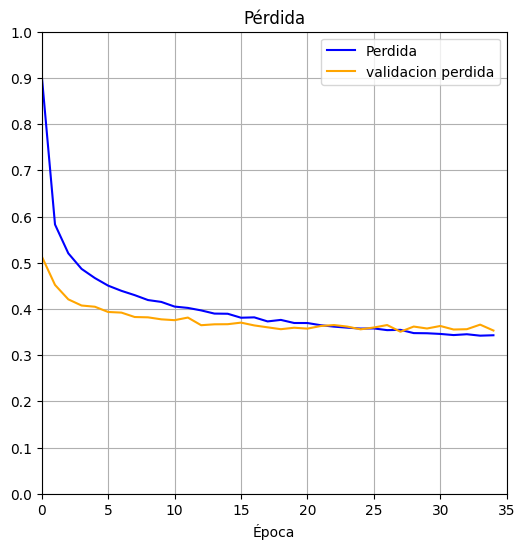

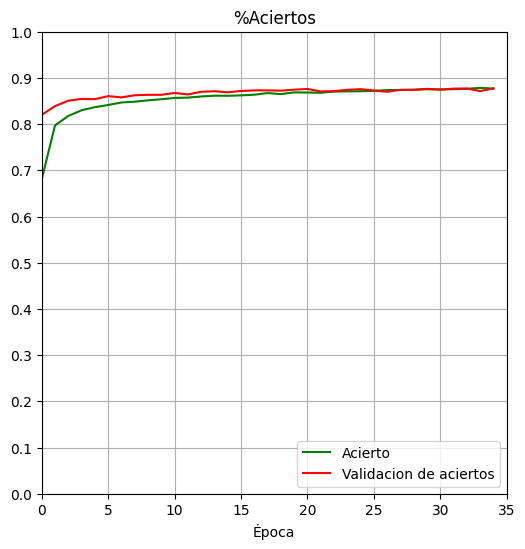

In [172]:
#tamaño de la cuadricula
plt.figure(figsize=(6, 6))

#Imprimimos la perdida en cada epoca
plt.plot(h2.history['loss'], color="blue", label="Perdida")
plt.plot(h2.history['val_loss'], color="orange", label="validacion perdida")

plt.title('Pérdida')
plt.legend()
plt.axis([0,35,0,1])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Época')
plt.grid(True)
plt.show()

#Imprimimos los aciertos en cada epoca
plt.figure(figsize=(6, 6))

plt.plot(h2.history['accuracy'], color="green", label="Acierto")
plt.plot(h2.history['val_accuracy'], color="red",label="Validacion de aciertos")

plt.title('%Aciertos')
plt.legend(loc="lower right")
plt.axis([0,35,0,1])
#plt.ylim(0.6,1)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xlabel('Época')
plt.grid(True)
plt.show()

###**1.7.1 Analisis de `red2`**

Para este modelo `red2` aplicamos diferentes metricas; usamos `ReLu` como funcion de activacion, utilizamos `Adam` como optimizer y para regularizar usamos capas `Dropout (0,3)`.

Como primer cambio podemos notar como la perdida ha disminuido. `red` tendia a 0,4 mientras que `red2` tiende a 0,35. Esto nos indica que con los cambios realizados el modelo consiguio un menor margen de error, generalizando de mejor manera.

A su vez, los aciertos aumentaron ligeramente pues ahora son de un 87%. Si bien no es cambio grande, nos indica que el modelo ha mejorado al aplicar regularizacion y cambio de optimizador


##**1.8 Utilizando la funcion de activacion `ReLu`, regularizando con Early stopping y Dropout.**
---

In [216]:

from keras.callbacks import EarlyStopping

# 1. Definición de la red
red3 = keras.Sequential()
red3.add(keras.layers.Dense(c1, input_dim=N, activation='relu', name='primera_capa'))
red2.add(keras.layers.Dropout(0.3))
red3.add(keras.layers.Dense(c2, activation='relu', name='segunda_capa'))
red2.add(keras.layers.Dropout(0.3))
red3.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red3.summary()

# 2. Configuración del EarlyStopping
es = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# 3. Compilación
red3.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=['accuracy']
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ primera_capa (Dense)            │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segunda_capa (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_de_output (Dense)          │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [217]:
# 4. Entrenamiento con el callback
h3 = red3.fit(
    X_train_images, Y_train_labels,
    epochs=50,
    batch_size=128,
    validation_data=(X_test_images, Y_test_labels),
    verbose=1,
    callbacks=[es]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8013 - loss: 0.5917 - val_accuracy: 0.8425 - val_loss: 0.4493
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8557 - loss: 0.4087 - val_accuracy: 0.8566 - val_loss: 0.4097
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8684 - loss: 0.3728 - val_accuracy: 0.8591 - val_loss: 0.3971
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8765 - loss: 0.3489 - val_accuracy: 0.8647 - val_loss: 0.3833
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8825 - loss: 0.3308 - val_accuracy: 0.8673 - val_loss: 0.3705
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8870 - loss: 0.3163 - val_accuracy: 0.8694 - val_loss: 0.3627
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8910 - loss: 0.3039 - val_accuracy: 0.8733 - val_loss: 0.3571
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8944 - loss: 0.2936 - val_accuracy: 0.

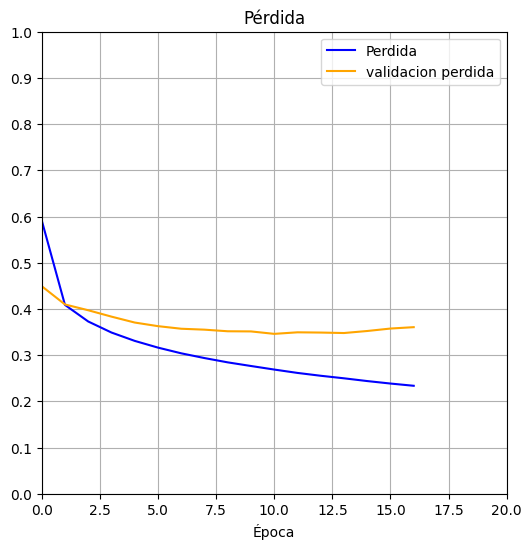

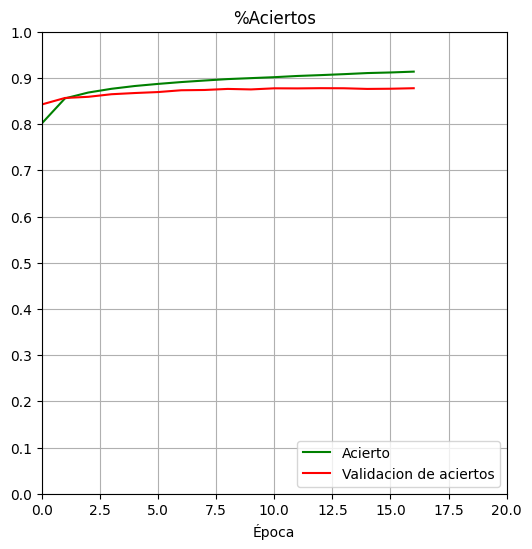

In [218]:
#tamaño de la cuadricula
plt.figure(figsize=(6, 6))

#Imprimimos la perdida en cada epoca
plt.plot(h3.history['loss'], color="blue", label="Perdida")
plt.plot(h3.history['val_loss'], color="orange", label="validacion perdida")

plt.title('Pérdida')
plt.legend()
plt.axis([0,20,0,1])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Época')
plt.grid(True)
plt.show()

#Imprimimos los aciertos en cada epoca
plt.figure(figsize=(6, 6))

plt.plot(h3.history['accuracy'], color="green", label="Acierto")
plt.plot(h3.history['val_accuracy'], color="red",label="Validacion de aciertos")

plt.title('%Aciertos')
plt.legend(loc="lower right")
plt.axis([0,20,0,1])
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xlabel('Época')
plt.grid(True)
plt.show()

### **1.8.2 Analisis de `red3`**

En este ultimo modelo `red3` podemos ver que, apesar de implementar Early Stopping, la validacion de datos no mejoro pero tampoco empeoro lo cual puede implicar que llegamos al mejor modelo usando la estructura actual sin llegar a utilizar capas mas profundas.

Por el lado de la perdida (loss) podemos ver que a la hora de entrenar el modelo tiende a 0,2 pero al generalizar el modelo podemos ver que se mantuvo muy similar al modelo `red2` con un 0,35 de perdida.

En cuanto a los aciertos podemos ver que en el entrenamiento sobrepaso el 90% de aciertos, pero al generalizar se mantuvo cerca del 87% (88% en este caso), muy similar a `red2`

#**2. Metricas derivadas de la matriz**


##**2.1 Inferencia y Etiquetado de Predicciones**

In [220]:
prob_modelo = red3.predict(X_test_images)
label_prediction = np.argmax(prob_modelo, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


##**2.2 Calculamos la matriz de confusion**

In [221]:
cm = confusion_matrix(test_labels, label_prediction)
cm

array([[819,   1,  27,  36,   7,   2, 104,   0,   4,   0],
       [  4, 964,   1,  25,   5,   0,   1,   0,   0,   0],
       [  9,   1, 817,  14, 112,   0,  46,   0,   0,   1],
       [ 22,   8,  20, 893,  37,   1,  17,   0,   2,   0],
       [  0,   0, 100,  29, 825,   0,  45,   0,   1,   0],
       [  0,   0,   0,   1,   0, 957,   0,  23,   2,  17],
       [117,   1, 118,  40,  85,   0, 634,   0,   5,   0],
       [  0,   0,   0,   0,   0,  19,   0, 954,   0,  27],
       [  4,   1,  10,   7,   4,   2,  10,   4, 957,   1],
       [  0,   0,   0,   0,   0,   9,   1,  35,   0, 955]])

##**2.3 Visualizamos la matriz de confusion**

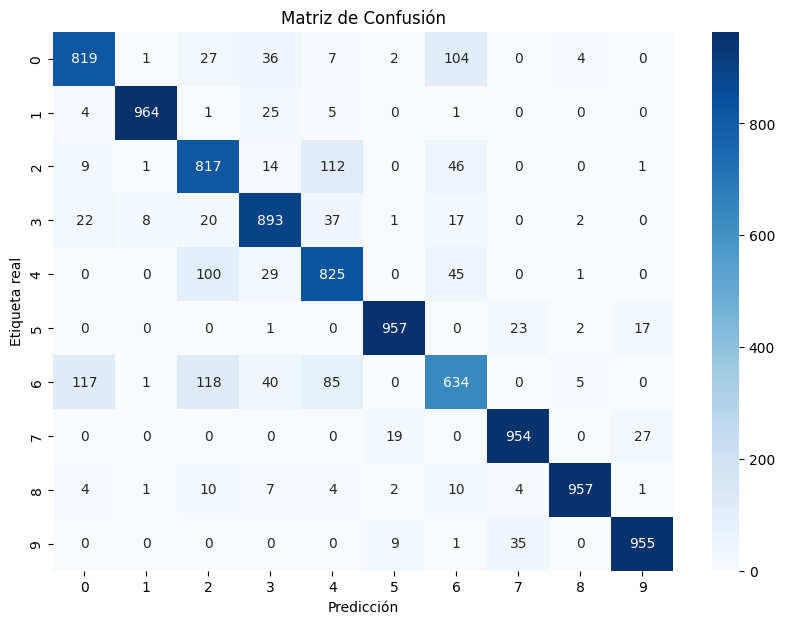

In [234]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión")
plt.show()

##**2.4 Métricas globales derivadas de la matriz de confusión**

In [232]:
acc = accuracy_score(test_labels, label_prediction)
prec_macro = precision_score(test_labels, label_prediction, average='macro')
rec_macro = recall_score(test_labels, label_prediction, average='macro')
f1_macro = f1_score(test_labels, label_prediction, average='macro')

prec_weighted = precision_score(test_labels, label_prediction, average='weighted')
rec_weighted = recall_score(test_labels, label_prediction, average='weighted')
f1_weighted = f1_score(test_labels, label_prediction, average='weighted')

balanced_acc = balanced_accuracy_score(test_labels, label_prediction)

print("Accuracy:", round(acc, 4))

print("Precision (macro):", round(prec_macro, 4))
print("Recall (macro):", round(rec_macro, 4))
print("F1-score (macro):", round(f1_macro, 4))
print()
print("Precision (weighted):", round(prec_weighted, 4))
print("Recall (weighted):", round(rec_weighted, 4))
print("F1-score (weighted):", round(f1_weighted, 4))
print()
print("Balanced Accuracy:", round(balanced_acc, 4))

Accuracy: 0.8775
Precision (macro): 0.8781
Recall (macro): 0.8775
F1-score (macro): 0.8771

Precision (weighted): 0.8781
Recall (weighted): 0.8775
F1-score (weighted): 0.8771

Balanced Accuracy: 0.8775


##**2.5 Reporte de clasificación**

In [224]:
print(classification_report(test_labels, label_prediction))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1000
           1       0.99      0.96      0.98      1000
           2       0.75      0.82      0.78      1000
           3       0.85      0.89      0.87      1000
           4       0.77      0.82      0.80      1000
           5       0.97      0.96      0.96      1000
           6       0.74      0.63      0.68      1000
           7       0.94      0.95      0.95      1000
           8       0.99      0.96      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



##**2.6 Cálculo de la Especificidad por clase**

In [228]:
specificity = {}

for i in range(len(cm)):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(np.delete(cm[:, i], i))
    specificity[i] = tn / (tn + fp)

for clase, valor in specificity.items():
    print(f"Clase {clase}: Especificidad = {valor:.4f}")

Clase 0: Especificidad = 0.9827
Clase 1: Especificidad = 0.9987
Clase 2: Especificidad = 0.9693
Clase 3: Especificidad = 0.9831
Clase 4: Especificidad = 0.9722
Clase 5: Especificidad = 0.9963
Clase 6: Especificidad = 0.9751
Clase 7: Especificidad = 0.9931
Clase 8: Especificidad = 0.9984
Clase 9: Especificidad = 0.9949


##**2.7 Mostrar métricas globales**

In [235]:
import pandas as pd

metrics_table = pd.DataFrame({
    "Precision (macro)": [prec_macro],
    "Recall (macro)": [rec_macro],
    "F1 (macro)": [f1_macro],
    "Precision (weighted)": [prec_weighted],
    "Recall (weighted)": [rec_weighted],
    "F1 (weighted)": [f1_weighted],
    "Accuracy": [acc],
    "Balanced Accuracy": [balanced_acc]
})

metrics_table

,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),Accuracy,Balanced Accuracy
0,0.878137,0.8775,0.87706,0.878137,0.8775,0.87706,0.8775,0.8775


##**2.8 Tabla por clase con todas las métricas**

In [240]:
per_class = pd.DataFrame({
    "Precision": precision_score(test_labels, label_prediction, average=None),
    "Recall": recall_score(test_labels, label_prediction, average=None),
    "F1-score": f1_score(test_labels, label_prediction, average=None),
    "Specificity": [specificity[i] for i in range(len(cm))]
})

per_class

,Precision,Recall,F1-score,Specificity
0,0.840000,0.819,0.829367,0.982667
1,0.987705,0.964,0.975709,0.998667
2,0.747484,0.817,0.780698,0.969333
3,0.854545,0.893,0.873350,0.983111
4,0.767442,0.825,0.795181,0.972222
5,0.966667,0.957,0.961809,0.996333
6,0.738928,0.634,0.682454,0.975111
7,0.938976,0.954,0.946429,0.993111
8,0.985582,0.957,0.971081,0.998444
9,0.954046,0.955,0.954523,0.994889


#**3. Conclusiones**



#3.1 Resumen
En este proyecto realizamos 3 pruebas para probar y mejorar la efectividad de una red neuronal utilizando el framework `Tensorflow` y la API `Keras` e implementando mejoras como regularizacion, diferentes funciones de activacion y diferentes optimizadores.

---

## Comparacion de redes neuronales

| Modelo | Función Activación | Optimizador | Value Accuracy | Observación |
| ---- | ---- | ---- | ---- | ---- |
| **`Red`** | Leaky ReLU | SGD | 85% | Modelo base; convergencia lenta. |
| **`Red2`** | ReLU | Adam | 87% | Mejora notable por optimizador<br> adaptativo. |
| **`Red3`** | ReLU | Adam | 88% | No hay mejora notable, lo cual nos lleva<br> a entender que el modelo llego al mejor<br> modelo con la estructura actual |






